# Scoring 02 — Stress Tests and Final Test Evaluation

Second step of the Scoring stage and the single point in the whole project where the
test labels are used. Every modelling decision is already locked: hyperparameters and
configurations (Fitting 03), calibrators (Fitting 04) and thresholds (Scoring 01) were
all chosen on training or validation data. Two stress tests run first: a
label-permutation check (50 pipelines refitted on shuffled labels — their whole AUROC
distribution must sit far below the real model's, proof that no information leaks from
the labels through the features or preprocessing) and a feature-drift check
(Kolmogorov–Smirnov tests confirming the three splits are exchangeable; features only,
labels untouched). The notebook then measures, on the untouched test split:
discrimination (AUROC, PR-AUC with bootstrap confidence intervals), calibration (Brier
decomposition), and expected loss at the pre-chosen thresholds — then compares how the
three metrics rank the models, which is the thesis's final research question. All
results are persisted to `test_results.json`.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from scipy.stats import ks_2samp
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve)

In [2]:
# Paths, seed, cost scenarios and bootstrap size.
SEED = 42
ARTIFACTS = Path("../artifacts")
COST_RATIOS = [5, 10, 20]
N_BOOTSTRAP = 1000
thresholds = json.loads((ARTIFACTS / "thresholds.json").read_text())

In [3]:
# Load the models and calibrators selected in the Fitting stage and the helper that
# turns raw model scores into calibrated probabilities (Platt calibrators are logistic
# regressions and use predict_proba; Beta and isotonic expose predict).
tuned = json.loads((ARTIFACTS / "tuned_params.json").read_text())
calibration = json.loads((ARTIFACTS / "calibration.json").read_text())
selected = tuned["selected"]
chosen_calibrator = calibration["selected_calibrator"]
models = {key: joblib.load(ARTIFACTS / "models" / f"{key}.joblib")
          for key in selected.values()}
calibrators = {key: joblib.load(ARTIFACTS / "calibrators" / f"{key}.joblib")
               for key in selected.values()}

def calibrated_probabilities(key, X):
    raw = models[key].predict_proba(X)[:, 1]
    calibrator = calibrators[key]
    if chosen_calibrator[key] == "platt":
        p = calibrator.predict_proba(raw.reshape(-1, 1))[:, 1]
    else:
        p = np.asarray(calibrator.predict(raw)).ravel()
    return np.clip(p, 0.0, 1.0)

print("models:", dict(selected), "  calibrators:", dict(chosen_calibrator))

models: {'logreg': 'logreg_C', 'rf': 'rf_C', 'xgb': 'xgb_C'}   calibrators: {'logreg_C': 'beta', 'rf_C': 'beta', 'xgb_C': 'isotonic'}


In [4]:
# Stress test 1 - label permutation. The logreg_C pipeline is refitted 50 times on
# randomly shuffled training labels and scored on the validation split each time. A
# SINGLE permutation is not enough here: a noise-fit produces random +/- coefficients,
# and because the Config C features are mutually correlated and individually
# risk-related, a random linear combination of them retains chance correlation with the
# real labels (single-permutation AUROCs range roughly 0.35-0.70). The leakage evidence
# is the DISTRIBUTION: if any information leaked from labels into features or
# preprocessing, permuted models could approach the real model's AUROC - instead the
# entire permutation distribution must sit far below it.
train_c = pd.read_parquet(ARTIFACTS / "train_configC.parquet")
val_c = pd.read_parquet(ARTIFACTS / "val_configC.parquet")
X_perm_train, y_perm_train = train_c.drop(columns="target"), train_c["target"].to_numpy()
N_PERMUTATIONS = 50
perm_aurocs = []
for k in range(N_PERMUTATIONS):
    rng_perm = np.random.default_rng(SEED + k)
    permuted_model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(penalty="l2", solver="lbfgs", max_iter=5000,
                                   class_weight="balanced", random_state=SEED,
                                   C=tuned["logreg_C"]["best_params"]["clf__C"])),
    ])
    permuted_model.fit(X_perm_train, rng_perm.permutation(y_perm_train))
    perm_aurocs.append(roc_auc_score(
        val_c["target"], permuted_model.predict_proba(val_c.drop(columns="target"))[:, 1]))
perm_aurocs = np.array(perm_aurocs)
real_val_auroc = [r for r in tuned["validation_metrics"]
                  if r["pipeline"] == "logreg_C"][0]["val_auroc"]
assert perm_aurocs.max() + 0.10 < real_val_auroc, \
    "a permuted-label model approaches real performance - investigate leakage"
print(f"permutation AUROCs ({N_PERMUTATIONS} refits): "
      f"mean {perm_aurocs.mean():.4f}  min {perm_aurocs.min():.4f}  max {perm_aurocs.max():.4f}")
print(f"real logreg_C validation AUROC: {real_val_auroc:.4f} "
      f"(margin over best permutation: {real_val_auroc - perm_aurocs.max():.4f}) - no leakage")

permutation AUROCs (50 refits): mean 0.5126  min 0.2386  max 0.7162
real logreg_C validation AUROC: 0.8573 (margin over best permutation: 0.1411) - no leakage


In [5]:
# Stress test 2 - feature drift. A two-sample Kolmogorov-Smirnov test per Config C
# feature compares the training distribution against validation and against test, with a
# Bonferroni-corrected significance level. A stratified random split should show no
# drift; significant drift would mean the splits are not exchangeable and the validation
# results would not transfer. Only FEATURE columns are compared - the test labels stay
# untouched until the evaluation cell below.
feature_cols = [c for c in train_c.columns if c != "target"]
test_features = pd.read_parquet(ARTIFACTS / "test_configC.parquet").drop(columns="target")
alpha_bonferroni = 0.05 / (len(feature_cols) * 2)
ks_rows = []
for col in feature_cols:
    for other_name, other in (("val", val_c), ("test", test_features)):
        stat, pval = ks_2samp(train_c[col], other[col])
        ks_rows.append({"feature": col, "comparison": f"train vs {other_name}",
                        "ks_stat": float(stat), "p_value": float(pval),
                        "significant_bonferroni": bool(pval < alpha_bonferroni)})
ks_drift = pd.DataFrame(ks_rows)
n_drift = int(ks_drift["significant_bonferroni"].sum())
print(f"KS drift checks: {len(ks_drift)} tests, Bonferroni alpha = {alpha_bonferroni:.2e}, "
      f"significant: {n_drift}")
if n_drift:
    print("WARNING - drifting features:")
    print(ks_drift[ks_drift.significant_bonferroni].to_string(index=False))
else:
    print("no significant drift: train, validation and test are exchangeable")
ks_drift.sort_values("p_value").head(10).round(4)

KS drift checks: 44 tests, Bonferroni alpha = 1.14e-03, significant: 0
no significant drift: train, validation and test are exchangeable


,feature,comparison,ks_stat,p_value,significant_bonferroni
7,monthly_income_t,train vs test,0.0071,0.2058,False
9,open_credit_lines_and_loans_t,train vs test,0.0065,0.2996,False
24,delinquency_rate,train vs val,0.0064,0.3078,False
22,combined_delinq_flag,train vs val,0.0061,0.3662,False
20,weighted_delinq_score,train vs val,0.0061,0.3662,False
6,monthly_income_t,train vs val,0.0051,0.6003,False
32,zero_flag_past_due_30_59,train vs val,0.0050,0.6227,False
14,past_due_30_59,train vs val,0.0050,0.6227,False
4,debt_ratio_t,train vs val,0.0047,0.7042,False
5,debt_ratio_t,train vs test,0.0046,0.7179,False


In [6]:
# The single point in the project where the test LABELS enter the analysis: load the
# test matrices once and produce calibrated probabilities for the three selected models.
# (The drift check above compared test feature distributions only.)
y_test = pd.read_parquet(ARTIFACTS / "test_configA.parquet")["target"].to_numpy()
probabilities = {}
for family, key in selected.items():
    cfg = key.split("_")[1]
    X_test = pd.read_parquet(ARTIFACTS / f"test_config{cfg}.parquet").drop(columns="target")
    probabilities[key] = calibrated_probabilities(key, X_test)
print(f"test rows: {len(y_test):,}  default rate {y_test.mean():.4%}")

test rows: 29,879  default rate 6.7004%


In [7]:
# Discrimination on the test split with paired bootstrap 95% confidence intervals (the
# same resample indices for every model, so the intervals are directly comparable). A
# single bootstrap helper - boot_ci(fn, p), where fn(y, p) returns the metric - is defined
# here and reused for the reliability and expected-loss CIs further down, so EVERY interval
# in this notebook is resampled on the identical indices. That shared routine is what makes
# the cross-metric comparison (and the rank-1-vs-rank-2 CI overlap read) legitimate.
rng = np.random.default_rng(SEED)
boot_idx = [rng.integers(0, len(y_test), len(y_test)) for _ in range(N_BOOTSTRAP)]

def boot_ci(fn, p):
    """Paired-bootstrap point estimate and 95% CI for fn(y, p), reusing boot_idx."""
    point = fn(y_test, p)
    samples = np.array([fn(y_test[idx], p[idx]) for idx in boot_idx])
    return point, float(np.percentile(samples, 2.5)), float(np.percentile(samples, 97.5))

rows = []
for key, p in probabilities.items():
    auroc, auroc_lo, auroc_hi = boot_ci(roc_auc_score, p)
    pr, pr_lo, pr_hi = boot_ci(average_precision_score, p)
    rows.append({"model": key, "AUROC": auroc, "AUROC_lo": auroc_lo, "AUROC_hi": auroc_hi,
                 "PR_AUC": pr, "PR_lo": pr_lo, "PR_hi": pr_hi})
discrimination = pd.DataFrame(rows).set_index("model")
discrimination.round(4)

,AUROC,AUROC_lo,AUROC_hi,PR_AUC,PR_lo,PR_hi
model,,,,,,
logreg_C,0.8589,0.8500,0.8681,0.4045,0.3808,0.4272
rf_C,0.8639,0.8556,0.8723,0.4078,0.3848,0.4288
xgb_C,0.8621,0.8537,0.8705,0.3939,0.3720,0.4161


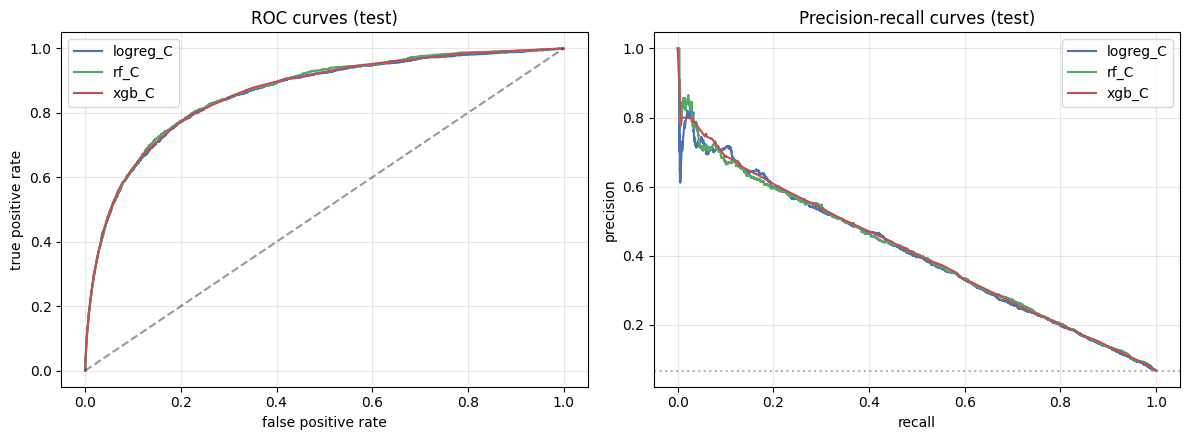

In [8]:
# ROC and precision-recall curves on the test split. The three models are nearly
# indistinguishable on the ROC view; the PR view (the harder task under class imbalance)
# separates them slightly more.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = {"logreg": "#4C72B0", "rf": "#55A868", "xgb": "#C44E52"}
for family, key in selected.items():
    p = probabilities[key]
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(fpr, tpr, color=colors[family], label=key)
    precision, recall, _ = precision_recall_curve(y_test, p)
    axes[1].plot(recall, precision, color=colors[family], label=key)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("true positive rate")
axes[0].set_title("ROC curves (test)")
axes[1].axhline(y_test.mean(), color="grey", ls=":", alpha=0.6)
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")
axes[1].set_title("Precision-recall curves (test)")
for ax in axes:
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# Calibration on the test split: Brier decomposition (BS = reliability - resolution +
# uncertainty), now with a paired-bootstrap 95% CI on the reliability component (via the
# shared boot_ci defined in the discrimination cell, so the same test bootstrap indices are
# reused). Reporting reliability with an interval - not a bare point estimate - lets the
# calibration ranking be read against sampling noise. Values in the 1e-4 range confirm the
# validation-chosen calibrators transfer to test.
def brier_decomposition(y, p):
    recalibrated = IsotonicRegression(out_of_bounds="clip").fit_transform(p, y)
    brier = float(np.mean((p - y) ** 2))
    brier_recalibrated = float(np.mean((recalibrated - y) ** 2))
    uncertainty = float(y.mean() * (1 - y.mean()))
    return {"brier": brier,
            "reliability": brier - brier_recalibrated,
            "resolution": uncertainty - brier_recalibrated,
            "uncertainty": uncertainty}

def reliability_component(y, p):
    recalibrated = IsotonicRegression(out_of_bounds="clip").fit_transform(p, y)
    return float(np.mean((p - y) ** 2) - np.mean((recalibrated - y) ** 2))

rows = []
for key, p in probabilities.items():
    decomp = brier_decomposition(y_test, p)
    _, rel_lo, rel_hi = boot_ci(reliability_component, p)
    rows.append({"model": key, **decomp, "reliability_lo": rel_lo, "reliability_hi": rel_hi})
calibration_table = pd.DataFrame(rows).set_index("model")
calibration_table.round(5)

,brier,reliability,resolution,uncertainty,reliability_lo,reliability_hi
model,,,,,,
logreg_C,0.04903,0.00036,0.01385,0.06251,0.00040,0.00062
rf_C,0.04893,0.00034,0.01392,0.06251,0.00041,0.00061
xgb_C,0.04898,0.00022,0.01375,0.06251,0.00021,0.00047


In [10]:
# Decision metrics at a threshold t: a borrower is rejected when the predicted default
# probability is at least t. Expected loss counts each missed defaulter (false negative)
# at CFN times the cost of each wrongly rejected good borrower (false positive, cost 1),
# averaged over the portfolio - the thesis's cost-sensitive objective.
def confusion_at(y, p, t):
    predicted_default = p >= t
    tp = int(np.sum((y == 1) & predicted_default))
    fn = int(np.sum((y == 1) & ~predicted_default))
    fp = int(np.sum((y == 0) & predicted_default))
    tn = int(np.sum((y == 0) & ~predicted_default))
    return tp, fn, fp, tn

def expected_loss(y, p, t, cfn):
    tp, fn, fp, tn = confusion_at(y, p, t)
    return (cfn * fn + fp) / len(y)

def threshold_metrics(y, p, t):
    tp, fn, fp, tn = confusion_at(y, p, t)
    n_pos, n_neg = tp + fn, fp + tn
    return {"approval_rate": (tn + fn) / len(y),
            "fnr": fn / n_pos if n_pos else np.nan,
            "fpr": fp / n_neg if n_neg else np.nan}

In [11]:
# Decision metrics on the test split at the thresholds chosen on val-eval, applied here
# without any re-optimisation, now with paired-bootstrap 95% CIs on each expected loss
# (same test bootstrap indices via boot_ci). For each model: the naive 0.5, the F1-optimal
# and the three cost-optimal policies, with EL and its CI under every cost scenario.
rows = []
for key, p in probabilities.items():
    named = {"naive": 0.50, "f1": thresholds[key]["f1"]}
    named.update({f"cost_{r}": thresholds[key]["cost_optimal"][str(r)]
                  for r in COST_RATIOS})
    for label, t in named.items():
        row = {"model": key, "policy": label, "threshold": t,
               **threshold_metrics(y_test, p, t)}
        for ratio in COST_RATIOS:
            el, el_lo, el_hi = boot_ci(
                lambda y, pp, t=t, ratio=ratio: expected_loss(y, pp, t, cfn=ratio), p)
            row[f"EL@{ratio}"] = el
            row[f"EL@{ratio}_lo"] = el_lo
            row[f"EL@{ratio}_hi"] = el_hi
        rows.append(row)
cost_table = pd.DataFrame(rows)
cost_table.round(4)

,model,policy,threshold,approval_rate,fnr,fpr,EL@5,EL@5_lo,EL@5_hi,EL@10,EL@10_lo,EL@10_hi,EL@20,EL@20_lo,EL@20_hi
0,logreg_C,naive,0.5000,0.9821,0.8292,0.0069,0.2842,0.2708,0.2968,0.5620,0.5357,0.5876,1.1176,1.0651,1.1679
1,logreg_C,f1,0.1900,0.9058,0.4705,0.0630,0.2164,0.2062,0.2255,0.3740,0.3529,0.3921,0.6893,0.6472,0.7252
2,logreg_C,cost_5,0.1720,0.8977,0.4471,0.0700,0.2151,0.2048,0.2242,0.3648,0.3451,0.3829,0.6644,0.6254,0.7004
3,logreg_C,cost_10,0.0880,0.8062,0.2867,0.1565,0.2421,0.2330,0.2500,0.3381,0.3213,0.3532,0.5302,0.4964,0.5607
4,logreg_C,cost_20,0.0550,0.7167,0.1908,0.2455,0.2930,0.2856,0.3001,0.3569,0.3443,0.3705,0.4848,0.4594,0.5118
5,rf_C,naive,0.5000,0.9812,0.8267,0.0077,0.2842,0.2706,0.2968,0.5611,0.5344,0.5862,1.1150,1.0618,1.1650
6,rf_C,f1,0.2400,0.9244,0.5240,0.0469,0.2193,0.2082,0.2286,0.3948,0.3736,0.4129,0.7459,0.7041,0.7826
7,rf_C,cost_5,0.1720,0.9042,0.4610,0.0640,0.2142,0.2038,0.2233,0.3686,0.3486,0.3867,0.6775,0.6380,0.7133
8,rf_C,cost_10,0.0860,0.8117,0.2782,0.1499,0.2331,0.2248,0.2415,0.3263,0.3108,0.3418,0.5127,0.4818,0.5432
9,rf_C,cost_20,0.0476,0.6607,0.1503,0.3027,0.3327,0.3254,0.3399,0.3831,0.3707,0.3942,0.4839,0.4601,0.5055


In [12]:
# Final ranking comparison - the thesis's last research question: do discrimination,
# calibration and expected loss agree on which model is best? Each model's expected loss
# is read at its own cost-optimal threshold for the matching scenario. Rank 1 = best
# (highest AUROC, lowest reliability, lowest expected loss). For each metric we also report
# whether the rank-1 and rank-2 models' 95% CIs OVERLAP - if they do, the disagreement
# between metrics is at the point-estimate level, within sampling noise.
ranking = pd.DataFrame(index=list(selected.values()))
ranking["AUROC"] = discrimination["AUROC"].rank(ascending=False).astype(int)
ranking["reliability"] = calibration_table["reliability"].rank().astype(int)
for ratio in COST_RATIOS:
    at_own_optimum = cost_table[cost_table.policy == f"cost_{ratio}"].set_index("model")
    ranking[f"EL@{ratio}"] = at_own_optimum[f"EL@{ratio}"].rank().astype(int)

def _overlap(lo1, hi1, lo2, hi2):
    return not (hi1 < lo2 or hi2 < lo1)

def _top2_overlap(table, value_col, lo_col, hi_col, ascending):
    order = table[value_col].sort_values(ascending=ascending)
    m1, m2 = order.index[0], order.index[1]
    return _overlap(table.loc[m1, lo_col], table.loc[m1, hi_col],
                    table.loc[m2, lo_col], table.loc[m2, hi_col])

ci_overlap = {
    "AUROC": _top2_overlap(discrimination, "AUROC", "AUROC_lo", "AUROC_hi", ascending=False),
    "reliability": _top2_overlap(calibration_table, "reliability",
                                 "reliability_lo", "reliability_hi", ascending=True),
}
for ratio in COST_RATIOS:
    at = cost_table[cost_table.policy == f"cost_{ratio}"].set_index("model")
    ci_overlap[f"EL@{ratio}"] = _top2_overlap(at, f"EL@{ratio}",
                                              f"EL@{ratio}_lo", f"EL@{ratio}_hi", ascending=True)

print("rank 1 = best per column; disagreement between columns means the metrics")
print("would select different models - the core finding discussed in the thesis.")
print("rank-1 vs rank-2 95% CI overlap (True = difference within sampling noise):")
print("  " + "  ".join(f"{m}={v}" for m, v in ci_overlap.items()))
ranking

rank 1 = best per column; disagreement between columns means the metrics
would select different models - the core finding discussed in the thesis.
rank-1 vs rank-2 95% CI overlap (True = difference within sampling noise):
  AUROC=True  reliability=True  EL@5=True  EL@10=True  EL@20=True


,AUROC,reliability,EL@5,EL@10,EL@20
logreg_C,3,3,2,3,2
rf_C,1,2,1,1,1
xgb_C,2,1,3,2,3


In [13]:
# Permutation importance on the VAL-EVAL rows (not test - the test labels are used only
# for the evaluation above). It shows which features each selected model actually relies on
# - the mechanism behind "the value of feature engineering depends on the model family" -
# and reports a grouped delinquency-family total, because collinear twins understate their
# importance when permuted one at a time. Computed on the model's PR-AUC (average
# precision), the project's headline metric.
from sklearn.inspection import permutation_importance

eval_idx = np.array(calibration["val_eval_idx"])
y_val_full = pd.read_parquet(ARTIFACTS / "val_configA.parquet")["target"].to_numpy()
yve = y_val_full[eval_idx]
DELINQ_GROUP = ["weighted_delinq_score", "combined_delinq_flag", "delinquency_rate",
                "util_delinq_interaction", "zero_flag_past_due_30_59",
                "zero_flag_past_due_60_89", "zero_flag_past_due_90",
                "past_due_30_59", "past_due_60_89", "past_due_90"]
perm_summary = {}
for family, key in selected.items():
    cfg = key.split("_")[1]
    Xve = pd.read_parquet(ARTIFACTS / f"val_config{cfg}.parquet").drop(columns="target").iloc[eval_idx]
    pi = permutation_importance(models[key], Xve, yve, scoring="average_precision",
                                n_repeats=10, random_state=SEED, n_jobs=1)
    imp = pd.Series(pi.importances_mean, index=Xve.columns).sort_values(ascending=False)
    group_total = float(imp[[c for c in imp.index if c in DELINQ_GROUP]].sum())
    perm_summary[key] = {"top": imp.head(8).round(5).to_dict(),
                         "delinquency_family_total": group_total}
    print(f"{key}: top feature '{imp.index[0]}' ({imp.iloc[0]:.5f}); "
          f"delinquency-family total {group_total:.5f}")
perm_summary

logreg_C: top feature 'revolving_util_band' (0.06493); delinquency-family total 0.05357


rf_C: top feature 'util_delinq_interaction' (0.03852); delinquency-family total 0.08790


xgb_C: top feature 'util_delinq_interaction' (0.03742); delinquency-family total 0.09195


{'logreg_C': {'top': {'revolving_util_band': 0.06493,
   'zero_flag_past_due_90': 0.01989,
   'mahalanobis_log': 0.01538,
   'combined_delinq_flag': 0.0134,
   'zero_flag_past_due_60_89': 0.01017,
   'sentinel_flag': 0.00653,
   'age_lifestage': 0.00503,
   'zero_flag_past_due_30_59': 0.00401},
  'delinquency_family_total': 0.053572283956647405},
 'rf_C': {'top': {'util_delinq_interaction': 0.03852,
   'revolving_util_band': 0.02546,
   'weighted_delinq_score': 0.01847,
   'delinquency_rate': 0.01693,
   'combined_delinq_flag': 0.0167,
   'debt_ratio_t': 0.00839,
   'debt_burden_per_dependent': 0.00323,
   'monthly_income_t': 0.00305},
  'delinquency_family_total': 0.08790117338307822},
 'xgb_C': {'top': {'util_delinq_interaction': 0.03742,
   'delinquency_rate': 0.02746,
   'revolving_util_band': 0.02636,
   'weighted_delinq_score': 0.02405,
   'debt_ratio_t': 0.01235,
   'mahalanobis_log': 0.00634,
   'open_credit_lines_and_loans_t': 0.00432,
   'age_lifestage': 0.00378},
  'delinque

In [14]:
# Persist everything this notebook established as the project's final evidence
# artifact: stress-test outcomes, test discrimination with confidence intervals, the
# Brier decomposition (now with reliability CIs), the full decision-metric table (now with
# expected-loss CIs), the metric-ranking comparison with its rank-1-vs-rank-2 CI overlap,
# and the val-eval permutation importance. The thesis quotes its test-stage numbers here.
test_results = {
    "seed": SEED,
    "n_bootstrap": N_BOOTSTRAP,
    "n_test": int(len(y_test)),
    "selected_models": dict(selected),
    "selected_calibrators": dict(chosen_calibrator),
    "stress_tests": {
        "label_permutation": {
            "n_permutations": N_PERMUTATIONS,
            "auroc_mean": float(perm_aurocs.mean()),
            "auroc_min": float(perm_aurocs.min()),
            "auroc_max": float(perm_aurocs.max()),
            "real_val_auroc": float(real_val_auroc),
            "margin_over_best_permutation": float(real_val_auroc - perm_aurocs.max()),
        },
        "ks_drift_n_significant_bonferroni": n_drift,
        "ks_drift": ks_drift.round(6).to_dict(orient="records"),
    },
    "discrimination": discrimination.round(6).reset_index().to_dict(orient="records"),
    "calibration": calibration_table.round(6).reset_index().to_dict(orient="records"),
    "cost_table": cost_table.round(6).to_dict(orient="records"),
    "ranking": ranking.reset_index().rename(columns={"index": "model"}).to_dict(orient="records"),
    "ranking_ci_overlap": ci_overlap,
    "permutation_importance": perm_summary,
}
(ARTIFACTS / "test_results.json").write_text(json.dumps(test_results, indent=2))
print("saved: test_results.json (incl. reliability/EL CIs, CI overlap, permutation importance)")

saved: test_results.json (incl. reliability/EL CIs, CI overlap, permutation importance)
